# <center> Electric Vehicle Dataset 2024

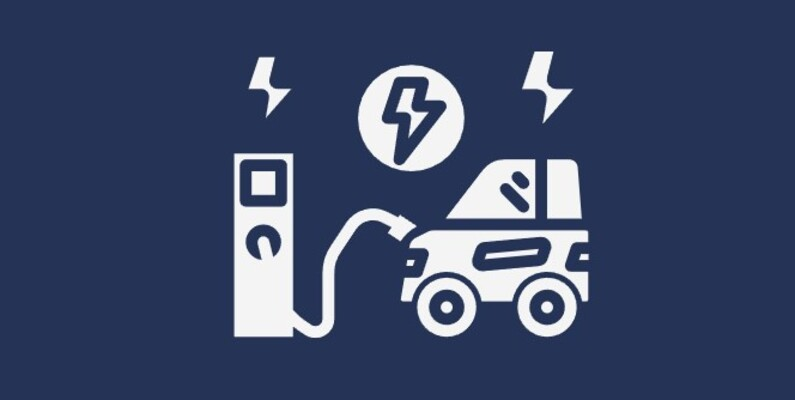

The dataset comprises information on electric vehicles (EVs) sourced from the website https://ev-database.org/ (Apr 2024) for strictly learning purpose. The clean dataset consists of 351 rows, 16 columns and includes information about various electric vehicle models, their specifications, and pricing details across different regions, and additional features.

The dataset used is **'cars_data_RAW.csv'** - the raw file is chosen to practice data cleaning

#### Explaining the columns
- Brand: The brand of the electric vehicle
- Model: The model name of the electric vehicle
- Battery: The battery capacity of the electric vehicle (in kWh)
- km_of_range: The range of the electric vehicle in kilometers
- 0-100: Acceleration time from 0 to 100 km/h (in seconds)
- Top_Speed: The maximum speed of the electric vehicle in km/h
- Range: The estimated range of the electric vehicle
- Efficiency: The efficiency of the electric vehicle (Wh/km)
- Fastcharge: The fast charging capability of the electric vehicle
- Price_in_Germany_before_incentives: Price of the electric vehicle in Germany before incentives
- Price_in_The_Netherlands_before_incentives: Price of the electric vehicle in the Netherlands before incentives
- Price_in_the_United_Kingdom_after_incentives: Price of the electric vehicle in the United Kingdom after incentives
- Drive_Configuration: The drive configuration of the electric vehicle
- Tow_Hitch: Whether a tow hitch is possible for the electric vehicle
- Towing_capacity_in_kg: The towing capacity of the electric vehicle in kilograms

### Importing necessary libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd

from IPython.display import display

### Loading and viewing the dataset

In [2]:
# Stop long decimals from cluttering the screen.

pd.set_option('display.float_format', lambda x: '%.1f' % x)

In [3]:
# Make a reference to the cars_data_RAW.csv file path
csv_path = Path('./data/cars_data_RAW.csv')

# Import the cars_data_RAW.csv as a DataFrame
data = pd.read_csv(csv_path)

In [4]:
# Display a summary of the DataFrame (column names, non-null counts, and data types)
# This is useful for checking for missing values or incorrect data types
data.info()

# Preview the first 5 rows of the data in a formatted table
print("\n")
print("Displaying the first few rows")
display(data.head(3))

<class 'pandas.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Row_ID                               353 non-null    int64  
 1   title                                353 non-null    str    
 2   model                                353 non-null    str    
 3   battery                              353 non-null    float64
 4   price-range                          353 non-null    int64  
 5   0 - 100                              353 non-null    str    
 6   Top Speed                            353 non-null    str    
 7   Range*                               353 non-null    str    
 8   Efficiency*                          353 non-null    str    
 9   Fastcharge*                          353 non-null    str    
 10  Germany_price_before_incentives      340 non-null    str    
 11  Netherlands_price_before_incentives  322 no

,Row_ID,title,model,battery,price-range,0 - 100,Top Speed,Range*,Efficiency*,Fastcharge*,Germany_price_before_incentives,Netherlands_price_before_incentives,UK_price_after_incentives,Drive_Configuration,Tow_Hitch,Towing_capacity_in_kg,Number_of_seats
0,1,Tesla,Model 3,57.5,104,6.1 sec,201 km/h,415 km,139 Wh/km,690 km/h,"€41,970","€41,990","£39,990",Rear Wheel Drive,Towbar possible,1000.0,5
1,2,Tesla,Model Y,57.5,137,6.9 sec,217 km/h,350 km,164 Wh/km,580 km/h,"€45,970","€45,990","£44,990",Rear Wheel Drive,Towbar possible,1600.0,5
2,3,Tesla,Model Y Long Range Dual Motor,75.0,130,5.0 sec,217 km/h,435 km,172 Wh/km,670 km/h,"€55,970","€52,990","£52,990",All Wheel Drive,Towbar possible,1600.0,5


#### Rename column headers

In [5]:
data.rename(columns={
    'title': 'Brand',
    'model': 'Model',
    'battery': 'Battery',
    'price-range': 'KM_of_range',
    '0 - 100': '0-100',
    'Top Speed': 'Top_speed',
    'Range*': 'Range',
    'Efficiency*': 'Efficiency',
    'Fastcharge*': 'Fastcharge',
    'Tow_Hitch' : 'Towbar_possible',
}, inplace=True)

#### Calculating estimated USD price

In [6]:
# Clean the columns: 
# This removes 'N/A', strips out all non-numeric characters (like £, €, or spaces), 
# and safely converts the columns to pure float numbers.
cols_to_clean = [
    'UK_price_after_incentives', 
    'Netherlands_price_before_incentives', 
    'Germany_price_before_incentives'
]

for col in cols_to_clean:
    # Convert to string to safely use string methods, remove 'N/A', strip non-digits, and convert back to float
    data[col] = pd.to_numeric(
        data[col].astype(str).str.replace('N/A', '', regex=False).str.replace(r'[^\d.]', '', regex=True), 
        errors='coerce'
    )

# Pre-calculate the USD conversions for the entire columns at once
usd_from_uk = data['UK_price_after_incentives'] * 1.246
usd_from_nl = data['Netherlands_price_before_incentives'] * 0.55866
usd_from_de = data['Germany_price_before_incentives'] * 1.06

# Apply the fallback logic (UK -> NL -> DE) using .fillna()
# This takes the UK USD value. If it's NaN, it fills it with the NL USD value. If that's NaN, it fills with DE.
data['Estimated_US_Value'] = usd_from_uk.fillna(usd_from_nl).fillna(usd_from_de)

# Format Approx. in USD based on UK price column
data['Estimated_US_Value'] = data['Estimated_US_Value'].apply(
    lambda x: '{:,.0f}'.format(x) if pd.notna(x) else None
)

data[['UK_price_after_incentives', 'Netherlands_price_before_incentives', 'Germany_price_before_incentives', 'Estimated_US_Value']].head(5)

,UK_price_after_incentives,Netherlands_price_before_incentives,Germany_price_before_incentives,Estimated_US_Value
0,39990.0,41990.0,41970.0,"49,828"
1,44990.0,45990.0,45970.0,"56,058"
2,52990.0,52990.0,55970.0,"66,026"
3,49990.0,49990.0,50970.0,"62,288"
4,NaN,49990.0,49970.0,"27,927"


#### Correcting data type and format - trimming text in numeric columns

In [7]:
# List of labels to capture
numeric_labels = [
    "Battery", 
    "KM_of_range", 
    "0-100", 
    "Top_speed",
    "Range",
    "Efficiency",
    "Fastcharge",
    "Germany_price_before_incentives",
    "Netherlands_price_before_incentives",
    "UK_price_after_incentives",
    "Towing_capacity_in_kg",
    "Number_of_seats",
    "Estimated_US_Value",

]

for col in numeric_labels:
    # First we ensure the column is treated as a string
    # Then we use regex to replace non-numeric characters with nothing
    data[col] = data[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    
    # Finally we the cleaned string back to a numeric type (float or int)
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [8]:
# Convert all strings in the "Brand" column to uppercase
data["Brand"] = data["Brand"].str.upper()
# Verifying the change
data["Brand"].sample()

69    OPEL
Name: Brand, dtype: str

In [9]:
data_shape = data.shape
data_size = data.size
data_columns = data.columns

print(f"The pandas dataframe has {data_shape[0]} rows and {data_shape[1]} columns")
print(f"That would be {data_size} cells")
print(f"These are the column headers in the dataframe:\n{data_columns}")

The pandas dataframe has 353 rows and 18 columns
That would be 6354 cells
These are the column headers in the dataframe:
Index(['Row_ID', 'Brand', 'Model', 'Battery', 'KM_of_range', '0-100',
       'Top_speed', 'Range', 'Efficiency', 'Fastcharge',
       'Germany_price_before_incentives',
       'Netherlands_price_before_incentives', 'UK_price_after_incentives',
       'Drive_Configuration', 'Towbar_possible', 'Towing_capacity_in_kg',
       'Number_of_seats', 'Estimated_US_Value'],
      dtype='str')


### Checking for null count and duplicates

In [10]:
# Get null count and percentage and create two different dataframes with them
data_missing_count = pd.DataFrame(data.isnull().sum(), columns=['null_count']).reset_index()
data_missing_percentage = pd.DataFrame(data.isnull().mean()*100, columns=['null_percentage']).reset_index()

# pd merge the two dataframes
data_null = pd.merge(
    data_missing_count,
    data_missing_percentage,
    how = 'left',
    on = "index"
)

# Print table with null value count and percentage
print(data_null)

# Duplicate sum
duplicates = data.duplicated().sum()
display(f"Total duplicate rows: {duplicates:,}")

# Delete previously used variables to save memory
del data_missing_count
del data_missing_percentage

                                  index  null_count  null_percentage
0                                Row_ID           0              0.0
1                                 Brand           0              0.0
2                                 Model           0              0.0
3                               Battery           0              0.0
4                           KM_of_range           0              0.0
5                                 0-100           0              0.0
6                             Top_speed           0              0.0
7                                 Range           0              0.0
8                            Efficiency           0              0.0
9                            Fastcharge           3              0.8
10      Germany_price_before_incentives          13              3.7
11  Netherlands_price_before_incentives          31              8.8
12            UK_price_after_incentives         106             30.0
13                  Drive_Configur

'Total duplicate rows: 0'

### Handling null values

In [11]:
data["Towbar_possible"].value_counts()

Towbar_possible
Towbar possible    237
Name: count, dtype: int64

In [12]:
# -- Handling Tow_Hitch column
# Mapping known string to 1 and filling NaNs with 0
data['Towbar_possible'] = data['Towbar_possible'].map({'Towbar possible': 1}).fillna(0).astype(int)

# -- Handling Towing_capacity_in_kg
# Filling the NaNs with 0 and ensuring it is an integer
data['Towing_capacity_in_kg'] = data['Towing_capacity_in_kg'].fillna(0).astype(int)

# -- Grouped statistical imputation for "Fastcharge" variable
group_medians = data.groupby(['Brand', 'Battery'])['Fastcharge'].transform('median')

# Filling missing values in 'Fastcharge' using those calculated medians
data['Fastcharge'] = data['Fastcharge'].fillna(group_medians)

# Fallback, If a specific Brand+Battery combination has NO data at all (all are NaN), 
data['Fastcharge'] = data['Fastcharge'].fillna(data.groupby('Brand')['Fastcharge'].transform('median'))
data['Fastcharge'] = data['Fastcharge'].fillna(data['Fastcharge'].median())

#### Diff calculation - UK only used if no other choice

In [13]:
# Estimate missing prices in one country by using known prices from the other countries, based on the historical average price relationship (ratio) between those countries.
# Germany is used as the main anchor (base country).
# Ratio: UK / DE
mask_uk_de = data['Germany_price_before_incentives'].notna() & data['UK_price_after_incentives'].notna()
r_uk_de = (data.loc[mask_uk_de, 'UK_price_after_incentives'] / data.loc[mask_uk_de, 'Germany_price_before_incentives']).mean()

# Ratio: NL / DE
mask_nl_de = data['Germany_price_before_incentives'].notna() & data['Netherlands_price_before_incentives'].notna()
r_nl_de = (data.loc[mask_nl_de, 'Netherlands_price_before_incentives'] / data.loc[mask_nl_de, 'Germany_price_before_incentives']).mean()

# Ratio: UK / NL (In case Germany is missing but both UK and NL exist)
mask_uk_nl = data['UK_price_after_incentives'].notna() & data['Netherlands_price_before_incentives'].notna()
r_uk_nl = (data.loc[mask_uk_nl, 'UK_price_after_incentives'] / data.loc[mask_uk_nl, 'Netherlands_price_before_incentives']).mean()

# Updated Fill Logic
def fill_with_ratios(row):
    de = row['Germany_price_before_incentives']
    nl = row['Netherlands_price_before_incentives']
    uk = row['UK_price_after_incentives']
    
    # --- Fill Germany (DE) ---
    if pd.isna(de):
        if not pd.isna(nl):
            # Pref 1: Use Netherlands
            de = nl / r_nl_de
        elif not pd.isna(uk):
            # Pref 2: Only use UK if NL is also missing
            de = uk / r_uk_de
        row['Germany_price_before_incentives'] = de
            
    # --- Fill Netherlands (NL) ---
    if pd.isna(nl):
        if not pd.isna(de):
            # Pref 1: Use Germany
            nl = de * r_nl_de
        elif not pd.isna(uk):
            # Pref 2: Only use UK if DE is also missing
            nl = uk / r_uk_nl
        row['Netherlands_price_before_incentives'] = nl
            
    # --- Fill UK ---
    if pd.isna(uk):
        if not pd.isna(de):
            # Pref 1: Use Germany
            uk = de * r_uk_de
        elif not pd.isna(nl):
            # Pref 2: Use Netherlands
            uk = nl * r_uk_nl
        row['UK_price_after_incentives'] = uk
            
    return row

# Applying and finalizing results
data = data.apply(fill_with_ratios, axis=1)

print(f"Calculated Ratios -> UK/DE: {r_uk_de:.3f}, NL/DE: {r_nl_de:.3f}, UK/NL: {r_uk_nl:.3f}")

Calculated Ratios -> UK/DE: 0.911, NL/DE: 1.019, UK/NL: 0.900


#### Set correct dtypes

In [14]:
int_labels = [
    "KM_of_range", 
    "Top_speed",
    "Range",
    "Efficiency",
    "Fastcharge",
    "Germany_price_before_incentives",
    "Netherlands_price_before_incentives",
    "UK_price_after_incentives",
    "Towing_capacity_in_kg",
    "Number_of_seats",
]

for col in int_labels:
    # Force to numeric (NaNs are created for errors)
    data[col] = pd.to_numeric(data[col], errors='coerce')
    
    # 2. Round and cast to the nullable 'Int64' - Pandas extension not numpy's int64
    # We use .round(0) to ensure we aren't losing precision unexpectedly
    data[col] = data[col].round(0).astype('Int64')


In [15]:
# Final check before output
data.info()
display(data.head(3))

<class 'pandas.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Row_ID                               353 non-null    int64  
 1   Brand                                353 non-null    str    
 2   Model                                353 non-null    str    
 3   Battery                              353 non-null    float64
 4   KM_of_range                          353 non-null    Int64  
 5   0-100                                353 non-null    float64
 6   Top_speed                            353 non-null    Int64  
 7   Range                                353 non-null    Int64  
 8   Efficiency                           353 non-null    Int64  
 9   Fastcharge                           353 non-null    Int64  
 10  Germany_price_before_incentives      353 non-null    Int64  
 11  Netherlands_price_before_incentives  353 no

,Row_ID,Brand,Model,Battery,KM_of_range,0-100,Top_speed,Range,Efficiency,Fastcharge,Germany_price_before_incentives,Netherlands_price_before_incentives,UK_price_after_incentives,Drive_Configuration,Towbar_possible,Towing_capacity_in_kg,Number_of_seats,Estimated_US_Value
0,1,TESLA,Model 3,57.5,104,6.1,201,415,139,690,41970,41990,39990,Rear Wheel Drive,1,1000,5,49828
1,2,TESLA,Model Y,57.5,137,6.9,217,350,164,580,45970,45990,44990,Rear Wheel Drive,1,1600,5,56058
2,3,TESLA,Model Y Long Range Dual Motor,75.0,130,5.0,217,435,172,670,55970,52990,52990,All Wheel Drive,1,1600,5,66026


### Save file as csv/xlsx for further analysis

In [16]:
# Output saved in data folder
# data.to_csv('./data/cars_data_cleaned.csv',index=False) # Enable to save as csv
data.to_excel('./data/cars_data_cleaned.xlsx',index=False) # Enable to save as Excel